### colab 한글 설치

In [ ]:
!apt-get update -qq
!apt-get install -qq fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
!rm -rf ~/.cache/matplotlib

### colab 한글 테스트

In [ ]:
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font = fm.FontProperties(fname=font_path)
print(font.get_name())

NanumGothic


In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', family=font.get_name())
plt.rcParams['axes.unicode_minus'] = False

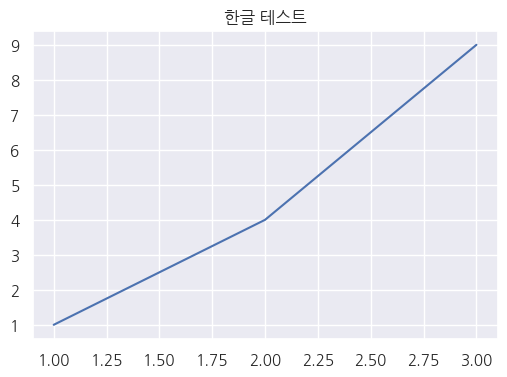

In [ ]:
plt.figure(figsize=(6, 4))
plt.title('한글 테스트')
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd
import glob

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 그래프 설정
sns.set()

plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split


# 차원 축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 학습 모델 저장을 위한 라이브러리
import pickle

In [ ]:
# 데이터를 읽어온다.
df = pd.read_parquet('/content/drive/MyDrive/파이널 프로젝트/C_D_NotCD/data/Seleted(C_D_NotCD)_all_train.parquet')
df.head(5)
df.tail(5)

,기준년월,ID,Group,_1순위카드이용금액,이용금액_R3M_신용체크,이용금액_R3M_신용,카드이용한도금액_B1M,카드이용한도금액_B2M,카드이용한도금액,CA한도금액,...,이용금액_오프라인_R3M,_2순위쇼핑업종_이용금액,_3순위업종_이용금액,이용금액_오프라인_B0M,_2순위업종_이용금액,_1순위업종_이용금액,_3순위쇼핑업종_이용금액,청구금액_R6M,청구금액_R3M,청구금액_B0
2399995,201812,TRAIN_399995,NotCD,5640,10755,7267,21097,21152,20070,10167,...,0,0,0,0,0,0,0,0,0,0
2399996,201812,TRAIN_399996,D,26357,27636,27636,78997,78140,84217,31159,...,25205,714,1547,4676,1810,5608,346,99849,37515,14402
2399997,201812,TRAIN_399997,C,17171,23187,23187,61315,63374,52612,19429,...,13267,400,2302,4516,2315,3634,305,41073,22274,5731
2399998,201812,TRAIN_399998,NotCD,0,0,0,10002,10001,10002,4228,...,0,0,0,0,0,0,0,0,0,0
2399999,201812,TRAIN_399999,NotCD,6984,21463,21463,70247,71252,86094,25133,...,0,0,894,0,926,2955,0,19948,9704,3422


In [ ]:
print(df.columns)

Index(['기준년월', 'ID', 'Group', '_1순위카드이용금액', '이용금액_R3M_신용체크', '이용금액_R3M_신용',
       '카드이용한도금액_B1M', '카드이용한도금액_B2M', '카드이용한도금액', 'CA한도금액', '이용금액_일시불_R12M',
       '이용금액_일시불_B0M', '이용금액_일시불_R3M', '이용금액_일시불_R6M', '최대이용금액_일시불_R12M',
       '쇼핑_도소매_이용금액', '이용금액_오프라인_R6M', '이용금액_오프라인_R3M', '_2순위쇼핑업종_이용금액',
       '_3순위업종_이용금액', '이용금액_오프라인_B0M', '_2순위업종_이용금액', '_1순위업종_이용금액',
       '_3순위쇼핑업종_이용금액', '청구금액_R6M', '청구금액_R3M', '청구금액_B0'],
      dtype='object')


In [ ]:
# pca 사용
# n_components : 축소될 결과의 컬럼 개수
from sklearn.decomposition import PCA
pca = PCA(n_components=20)
# 결과 데이터를 제거한다.
X = df.drop(['기준년월', 'ID', 'Group'], axis=1)
# 학습한다.
pca.fit(X)
# 데이터를 변환한다.
r1 = pca.transform(X)
r1

array([[-3.17487721e+04, -4.78599901e+04,  6.96128653e+04, ...,
         2.41984012e+03,  3.09033765e+02,  1.19930107e+02],
       [-3.93614690e+04, -6.11295640e+04, -2.02490505e+04, ...,
        -9.58946727e+02, -6.60932618e+02, -1.13003517e+02],
       [ 1.04310192e+05, -4.05504572e+02,  1.21679823e+05, ...,
        -1.17566630e+03, -7.41848986e+02,  7.91125528e+02],
       ...,
       [ 2.20970241e+04,  2.18377416e+03,  3.47010311e+03, ...,
         1.55662993e+02,  4.45962868e+01,  7.51949257e+02],
       [-1.00272824e+05, -2.70992676e+04, -4.83741315e+03, ...,
        -2.46374925e+02, -7.53505449e+01, -6.85170448e+01],
       [-1.00587192e+04,  5.45838947e+04,  5.46264689e+03, ...,
        -2.04878900e+03,  2.39485318e+02,  2.45902567e+02]])

In [ ]:
# 결과 데이터를 데이터프레임으로 변환
pca_df = pd.DataFrame(r1, columns=[f'p{i+1}' for i in range(r1.shape[1])])

# Segment 컬럼을 원본 df에서 가져와서 붙이기
pca_df['Group'] = df['Group'].values

# 결과 확인
pca_df.head()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p12,p13,p14,p15,p16,p17,p18,p19,p20,Group
0,-31748.772085,-47859.990109,69612.865323,-23461.163869,8129.317770,3390.812842,-473.876866,-1791.142380,7157.714500,-3508.991219,...,-868.618287,-985.110088,-2012.822089,-1949.503465,-1509.196094,703.649841,2419.840116,309.033765,119.930107,D
1,-39361.469044,-61129.563967,-20249.050456,-5648.775639,556.821789,2447.605291,248.967108,-1121.570552,3992.332019,-1249.344396,...,756.550565,6033.760358,386.351162,3346.685230,2189.137143,2333.634148,-958.946727,-660.932618,-113.003517,NotCD
2,104310.192493,-405.504572,121679.823301,-20312.690387,-9384.600360,10443.388306,7094.203110,544.686276,8658.754549,128.268515,...,5596.792352,-6705.633421,-3137.420426,2087.732459,-5617.806144,-954.635880,-1175.666302,-741.848986,791.125528,C
3,-21486.562371,-55770.074543,111562.385266,-21996.316906,11829.387992,-9935.054315,2320.371679,-5524.604805,10118.139557,1537.924369,...,-1862.507239,5628.705353,-854.362685,-849.243530,-2206.288042,1300.720259,2167.159045,1352.405333,-67.531392,D
4,39381.816938,219565.534399,3105.674843,88.853266,-359.026504,-1225.402435,5076.998325,-3114.139483,-606.641466,780.192228,...,-6015.592386,-1229.839172,606.140041,-1038.252665,-230.897776,-3157.368198,833.384237,874.948990,228.113652,NotCD


In [ ]:
pca_df.tail()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p12,p13,p14,p15,p16,p17,p18,p19,p20,Group
2399995,-86782.793778,-12576.465417,-5237.869447,2275.264152,-8090.741250,-6673.828864,1183.062721,-312.833839,17.464933,335.158349,...,2055.093508,179.930753,2072.766204,3902.244437,-797.234395,-1206.463583,-451.570497,-122.511687,-103.506748,NotCD
2399996,146110.882493,-23552.588678,-7.519600,-27306.243655,19595.008496,2651.897875,5107.358370,19011.107092,1838.005898,-4120.790178,...,4198.786668,2127.682687,-755.580610,1603.449867,1995.564358,-3454.094536,-3171.482786,-1230.998089,166.289729,D
2399997,22097.024052,2183.774159,3470.103111,6074.883731,-1976.587273,-2439.576963,-7669.301283,131.259947,1178.838304,-1469.103539,...,1707.971751,-81.159692,3199.238683,3603.687130,-1746.555444,-23.354593,155.662993,44.596287,751.949257,C
2399998,-100272.824205,-27099.267584,-4837.413150,-4013.278715,1317.939878,-928.073093,738.398447,-1347.982852,281.937570,-34.121529,...,-622.692843,-190.714658,1113.219293,-349.269299,-4.210785,-158.263859,-246.374925,-75.350545,-68.517045,NotCD
2399999,-10058.719152,54583.894744,5462.646893,6671.770985,-20098.919408,1407.550666,11110.187339,5749.402477,-3483.080702,-4101.361169,...,-2163.390196,-5223.970093,6540.032362,-350.768928,-201.655249,-52.343232,-2048.788999,239.485318,245.902567,NotCD


### 저장

In [ ]:
pca_df.to_csv('/content/drive/MyDrive/파이널 프로젝트/C_D_NotCD/(C_D_NotCD)_pca(20)_train.csv', index=False)

In [ ]:
pca_df.to_parquet('/content/drive/MyDrive/파이널 프로젝트/C_D_NotCD/(C_D_NotCD)_pca(20)_train.parquet', index=False)

## Test

In [ ]:
# 데이터를 읽어온다.
df_test = pd.read_parquet('/content/drive/MyDrive/파이널 프로젝트/C_D_NotCD/data/Seleted(C_D_NotCD)_all_test.parquet')
df_test.head(5)


,기준년월,ID,청구금액_R6M,청구금액_R3M,청구금액_B0,이용금액_일시불_R12M,_1순위카드이용금액,이용금액_R3M_신용체크,이용금액_일시불_B0M,이용금액_일시불_R3M,...,_2순위쇼핑업종_이용금액,_3순위업종_이용금액,카드이용한도금액_B1M,카드이용한도금액_B2M,카드이용한도금액,이용금액_오프라인_B0M,_2순위업종_이용금액,CA한도금액,_1순위업종_이용금액,_3순위쇼핑업종_이용금액
0,201807,TEST_00000,22151,11441,4931,49063,13852,21458,7650,20503,...,854,1880,49999,50006,50902,9877,2713,18131,4034,643
1,201807,TEST_00001,32878,20522,10152,7771,11065,18681,367,-1832,...,1154,1278,50000,50003,50080,4006,1321,16819,8398,1033
2,201807,TEST_00002,71867,50508,13223,73003,27071,40758,8547,25225,...,1178,2680,100053,100056,100045,11298,7271,30505,7594,1094
3,201807,TEST_00003,4986,4604,2112,7421,4827,5255,1270,2670,...,804,605,21035,19693,18508,976,2043,6402,2835,634
4,201807,TEST_00004,10758,6788,4406,10493,8011,16148,709,2982,...,774,1054,4291,3924,4033,4017,1364,0,3439,760


In [ ]:
# 불필요한 컬럼 제거
X_test = df_test.drop(['기준년월', 'ID'], axis=1)

In [ ]:
# train 데이터에서 feature 컬럼 리스트 확보
feature_columns = X.columns.tolist()

# test 데이터에서 동일한 컬럼, 동일한 순서로 선택
X_test = df_test[feature_columns]


In [ ]:
# transform
X_test_pca = pca.transform(X_test)

# DataFrame 변환
pca_columns = [f'p{i+1}' for i in range(X_test_pca.shape[1])]
pca_df_test = pd.DataFrame(X_test_pca, columns=pca_columns)

# ID 붙이기
pca_df_test['ID'] = df_test['ID'].values

In [ ]:
pca_df_test.tail()


,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,...,p12,p13,p14,p15,p16,p17,p18,p19,p20,ID
599995,-109088.921879,-42537.062400,-5276.456698,-4165.932541,1438.658337,-929.196275,605.807673,-1209.251537,315.044492,38.217938,...,-1854.365786,-157.467510,1221.978857,-327.970328,-5.558227,-164.233756,-253.671463,-97.299637,-69.227138,TEST_99995
599996,-60865.411620,30962.274345,-2668.692123,-1695.029144,-312.646415,-3672.225762,446.713914,-1814.455388,931.126831,1024.460636,...,1491.818948,28.859162,1536.725036,-444.490452,-264.425973,-916.837057,156.709530,-52.254248,-119.534352,TEST_99996
599997,-82587.816129,3867.357543,-3951.876597,-3703.551905,1066.346738,-914.110862,1101.197703,-1621.084265,220.560375,-244.154353,...,2450.444054,-262.098223,853.431497,-393.155726,-3.328020,-146.504497,-232.687239,-30.463120,-66.804142,TEST_99997
599998,361130.558876,-226736.549069,-149686.340654,-50885.918000,-83362.716177,-38147.375263,10547.710161,-3930.796550,-6260.321511,8922.920425,...,827.094100,-8583.194368,-26577.514514,-3492.882889,3936.643245,-2045.294262,-66.247872,2838.708766,-3273.334814,TEST_99998
599999,-38713.393899,82692.278204,-799.924980,-1976.492833,-1405.778098,-5738.157278,7773.300658,-3484.363744,1114.364932,-209.578783,...,2652.416598,315.959497,2153.113288,-958.967806,-120.828583,-657.526347,293.163735,234.868835,-148.743913,TEST_99999


In [ ]:
pca_df_test.to_csv('/content/drive/MyDrive/파이널 프로젝트/C_D_NotCD/(C_D_NotCD)_pca(20)_test.csv', index=False)

In [ ]:
pca_df_test.to_parquet('/content/drive/MyDrive/파이널 프로젝트/C_D_NotCD/(C_D_NotCD)_pca(20)_test.parquet', index=False)